# 09: Training Pipeline

Implements and validates the complete TFPnP training loop on CSD3.

By the end:
- All three gradient updates implemented (critic eq.15, π₁ eq.16, π₂ eq.17)
- Smoke-tested on real LION operator + pretrained DRUNet
- First training run on ~10 LIDC slices
- Training curve and policy behaviour visualisation

**Runs on CSD3** with LION operator, DRUNet, and GPU.

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
from collections import defaultdict, namedtuple
import math

import ct_tfpnp
from ct_tfpnp.models.policy   import ResNetActor_ADMM
from ct_tfpnp.models.critic   import ResNet_wobn
from ct_tfpnp.models.denoiser import DRUNetDenoiser
from ct_tfpnp.ct_ops.admm     import ADMMStep
from ct_tfpnp.ct_ops.fbp      import fbp as lion_fbp
from ct_tfpnp.evaluation.metrics import psnr_np as psnr, ls_scale
from ct_tfpnp.datasets.lidc import get_lion_split
from ct_tfpnp.experiments.parallel_beam_ct import experiment
from ct_tfpnp.training.replay_buffer import ReplayBuffer
from ct_tfpnp.training.environment import collect_episode
from ct_tfpnp.training.losses import (
    compute_critic_loss, compute_policy_loss_discrete, compute_policy_loss_continuous,
)

from LION.CTtools.ct_utils import make_operator

device = torch.device("cuda")
print(f"ct_tfpnp : {ct_tfpnp.__version__}")
print(f"device   : {device}")
print(f"GPU      : {torch.cuda.get_device_name()}")

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# ── Experiment config ─────────────────────────────────────────────────────
EXPERIMENT_NAME = "run_03_lion_split_val"
N_TRAIN = 50       # how many training images to use
N_VAL = 20         # how many validation images
NOISE_STD = 0.05  # quick visual check — full multi-noise evaluation is in NB10

# create output directory for figures
output_dir = Path("../figures/09")
output_dir.mkdir(parents=True, exist_ok=True)

ckpt_dir = Path(f"../results/learned/{EXPERIMENT_NAME}")
ckpt_dir.mkdir(parents=True, exist_ok=True)

# ── CT geometry ───────────────────────────────────────────────────────────
geo = experiment.experiment_params.geometry
op = make_operator(geo)

# ── DRUNet ────────────────────────────────────────────────────────────────
DENOISER_PATH = "/home/eaz21/rds/hpc-work/ct_reconstruction/results/baselines/drunet_gray.pth"
denoiser = DRUNetDenoiser(pretrained_path=DENOISER_PATH).to(device)
for p in denoiser.parameters():
    p.requires_grad_(False)
denoiser.eval()

admm_step = ADMMStep(op=op, denoiser=denoiser, n_x_steps=6)

# ── Load data using LION's built-in splits ────────────────────────────────
train_images, _ = get_lion_split("train", geometry=geo, device=device)
val_images, _ = get_lion_split("validation", geometry=geo, device=device)

train_images = train_images[:N_TRAIN]
val_images = val_images[:N_VAL]

print(f"Train: {len(train_images)} images | Val: {len(val_images)} images")
print(f"Shape: {train_images[0].shape}, range [{train_images[0].min():.4f}, {train_images[0].max():.4f}]")
print(f"Experiment: {EXPERIMENT_NAME}")

def _to_4d(t, device=None):
    if device is not None: t = t.to(device)
    return t.unsqueeze(0) if t.dim() == 3 else t

print("Setup complete.")

ct_tfpnp : 0.1.dev38+gc41030212.d20260611
device   : cuda
GPU      : NVIDIA A100-SXM4-80GB
Loaded DRUNet weights from /home/eaz21/rds/hpc-work/ct_reconstruction/results/baselines/drunet_gray.pth
Preparing patient list, this may take time....
Patient lists ready for train dataset
LION train split: 3300 images, range [0.0000, 2.4475]
Preparing patient list, this may take time....
Patient lists ready for validation dataset
LION validation split: 401 images, range [0.0000, 2.3958]
Train: 50 images | Val: 20 images
Shape: torch.Size([1, 512, 512]), range [0.0000, 2.4475]
Experiment: run_03_lion_split_val
Setup complete.


Check DRUNet works at LION's scale

In [2]:
# Verify DRUNet handles LION's native range [0, ~2.45]
gt_test = train_images[0]
print(f"Input range: [{gt_test.min():.3f}, {gt_test.max():.3f}]")

with torch.no_grad():
    denoised = denoiser(gt_test, sigma=2.0)
print(f"Output range: [{denoised.min():.3f}, {denoised.max():.3f}]")
print(f"PSNR (clean→denoised): {psnr(gt_test, denoised):.1f} dB")
print(f"Max diff: {(gt_test - denoised).abs().max():.4f}")
print("✓ DRUNet handles LION's range" if denoised.max() > 0.1 else "✗ Problem")

Input range: [0.000, 2.447]
Output range: [-0.010, 2.380]
PSNR (clean→denoised): 41.4 dB
Max diff: 0.3075
✓ DRUNet handles LION's range


Check full ADMM pipeline

In [3]:
# Verify FBP + ADMM at LION's scale
sino_clean = op.forward(gt_test)
SCALE = sino_clean.max() / gt_test.max()
torch.manual_seed(42)
sino_noisy = sino_clean / SCALE + 0.05 * (sino_clean / SCALE).std() * torch.randn_like(sino_clean)
y = sino_noisy * SCALE

x_fbp = lion_fbp(y, op)
x_fbp = ls_scale(gt_test, x_fbp).clamp(min=0)
fbp_psnr = psnr(gt_test, x_fbp)

x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
with torch.no_grad():
    for k in range(20):
        x, z, u = admm_step(x, z, u, y, sigma=2.0, mu=20.0)
x_admm = ls_scale(gt_test, x).clamp(min=0)
admm_psnr = psnr(gt_test, x_admm)

print(f"FBP PSNR:  {fbp_psnr:.2f} dB")
print(f"ADMM PSNR: {admm_psnr:.2f} dB")
print(f"Gain: +{admm_psnr - fbp_psnr:.2f} dB")

if admm_psnr > fbp_psnr + 5:
    print("✓ Pipeline works at LION's native range")
else:
    print("✗ Something is wrong — ADMM should gain >5 dB over FBP")

/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/torch.py:63: UserWarning: The parameter initial_value should be contiguous. It has been automatically made contiguous. Use `ts.link(x.contiguous())' to inhibit this warning. 
  warnings.warn(


FBP PSNR:  14.20 dB
ADMM PSNR: 25.83 dB
Gain: +11.63 dB
✓ Pipeline works at LION's native range


## 2. Replay Buffer

Simple experience replay buffer storing (state, action, reward, next_state) transitions.

In [4]:
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'sinogram'))

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        indices = np.random.choice(len(self.memory), batch_size, replace=False)
        return [self.memory[i] for i in indices]

    def __len__(self):
        return len(self.memory)

replay_buffer = ReplayBuffer(capacity=5000)
print(f"ReplayBuffer created (capacity={replay_buffer.capacity})")

ReplayBuffer created (capacity=5000)


## 3. Environment Rollout

Algorithm 1 lines 3–9: run the current policy through the ADMM environment to collect transitions. Each episode processes one image through N decision steps of m=5 ADMM iterations each.

In [5]:
def collect_episode(policy, admm_step, replay_buffer, gt, op,
                    noise_std=None, noise_levels=(0.05, 0.075, 0.10),
                    m=5, N=6, eta=0.05):
    """
    Run one episode through the ADMM environment.
    
    If noise_std is None, randomly samples from noise_levels (paper convention).
    If noise_std is a float, uses that fixed value.
    """
    device = gt.device

    # Randomly sample noise level if not specified (matches paper)
    if noise_std is None:
        noise_std = float(np.random.choice(noise_levels))

    # Generate noisy sinogram
    sino_clean = op.forward(gt)
    SCALE = sino_clean.max() / gt.max()
    sino_scaled = sino_clean / SCALE
    noise = noise_std * sino_scaled.std() * torch.randn_like(sino_scaled)
    sino_noisy = sino_scaled + noise
    y = sino_noisy * SCALE

    # FBP init
    x = lion_fbp(y, op)
    x = ls_scale(gt, x).clamp(min=0)
    z = x.clone()
    u = torch.zeros_like(x)
    noise_level = torch.tensor([noise_std], device=device)

    episode_rewards = []
    prev_psnr = psnr(gt, x)

    for t in range(N):
        iter_frac = torch.tensor([t / N], device=device)

        # Policy reads state → outputs actions
        with torch.no_grad():
            stop_logits, sigma_seq, mu_seq = policy(
                _to_4d(x), _to_4d(z), _to_4d(u), noise_level, iter_frac)
        stop_probs = F.softmax(stop_logits, dim=-1)
        stop = torch.bernoulli(stop_probs[:, 1]).bool().item()

        # Store state before ADMM steps
        state = (x.detach().clone(), z.detach().clone(), u.detach().clone(),
                 noise_level.clone(), iter_frac.clone())

        # Run m ADMM steps with policy's parameters
        with torch.no_grad():
            for i in range(m):
                x, z, u = admm_step(x, z, u, y,
                                     sigma=sigma_seq[0, i],
                                     mu=mu_seq[0, i])

        # Compute reward: ΔPSNR - η
        curr_psnr = psnr(gt, x)
        reward = (curr_psnr - prev_psnr) - eta
        prev_psnr = curr_psnr
        episode_rewards.append(reward)

        # Store transition — move to CPU to save GPU memory
        next_iter = torch.tensor([(t + 1) / N], device=device)
        next_state = (x.detach().clone(), z.detach().clone(), u.detach().clone(),
                      noise_level.clone(), next_iter.clone())
        action = (stop_logits.detach(), sigma_seq.detach(), mu_seq.detach())

        def _to_cpu(tensors):
            return tuple(t.cpu() for t in tensors)

        replay_buffer.push(
            _to_cpu(state),
            _to_cpu(action),
            torch.tensor([reward]),  # already scalar, CPU
            _to_cpu(next_state),
            y.detach().cpu(),
        )

        if stop:
            break

    return {
        'rewards': episode_rewards,
        'final_psnr': curr_psnr,
        'n_decisions': t + 1,
        'n_admm_steps': (t + 1) * m,
    }

print("collect_episode() defined.")

collect_episode() defined.


## 4. Critic Loss (Equation 15)

$$\mathcal{L}_\phi = \frac{1}{2}\mathbb{E}\left[(r + \gamma V_{\hat{\phi}}(s') - V_\phi(s))^2\right]$$

In [6]:
def compute_critic_loss(critic, target_critic, transitions, gamma=0.99):
    """TD loss for value network (eq. 15)."""
    device = next(critic.parameters()).device
    rewards, v_currs, v_nexts = [], [], []

    for t in transitions:
        s = tuple(_to_4d(x, device) for x in t.state)
        ns = tuple(_to_4d(x, device) for x in t.next_state)
        v_currs.append(critic(*s).squeeze())
        with torch.no_grad():
            v_nexts.append(target_critic(*ns).squeeze())
        rewards.append(t.reward.to(device).squeeze())

    v_curr = torch.stack(v_currs)
    v_next = torch.stack(v_nexts)
    r = torch.stack(rewards)

    td_target = r + gamma * v_next
    loss = 0.5 * F.mse_loss(v_curr, td_target)

    return loss, {
        'critic_loss': loss.item(),
        'mean_reward': r.mean().item(),
        'mean_v': v_curr.mean().item(),
    }

print("compute_critic_loss() defined.  (eq. 15)")

compute_critic_loss() defined.  (eq. 15)


## 5. Policy Loss π₁: REINFORCE with Advantage (Eq. 16)

$$\nabla_{\theta_1} J = \mathbb{E}\left[\nabla_{\theta_1}\log\pi_1(a_1|s)\cdot A^\pi(s,a)\right]$$

In [7]:
def compute_policy_loss_discrete(policy, critic, transitions, gamma=0.99):
    """REINFORCE loss for termination policy pi_1 (eq. 16)."""
    device = next(policy.parameters()).device
    advantages, log_probs_a1 = [], []

    for t in transitions:
        s = tuple(_to_4d(x, device) for x in t.state)
        ns = tuple(_to_4d(x, device) for x in t.next_state)

        with torch.no_grad():
            v_s = critic(*s).squeeze()
            v_ns = critic(*ns).squeeze()
        advantage = (t.reward.to(device).squeeze() + gamma * v_ns - v_s).detach()
        advantages.append(advantage)

        stop_logits, _, _ = policy(*s)
        log_probs = F.log_softmax(stop_logits, dim=-1)
        a1 = (F.softmax(t.action[0].to(device), dim=-1)[:, 1] > 0.5).long()
        log_probs_a1.append(log_probs[0, a1.item()])

    advantages = torch.stack(advantages)
    log_probs_a1 = torch.stack(log_probs_a1)
    loss = -(log_probs_a1 * advantages).mean()

    return loss, {
        'policy_loss_discrete': loss.item(),
        'mean_advantage': advantages.mean().item(),
    }

print("compute_policy_loss_discrete() defined.  (eq. 16)")

compute_policy_loss_discrete() defined.  (eq. 16)


## 6. Policy Loss π₂: Model-Based DDPG (Eq. 17)

$$\nabla_{\theta_2} J = \mathbb{E}\left[\nabla_{\theta_2} V_\phi(p(s, \pi_2(s)))\right]$$

Gradients flow: θ₂ → (σ,μ) → ADMM → s' → V_φ(s')

In [8]:
def compute_policy_loss_continuous(policy, critic, admm_step, transitions,
                                    m=5, N=6):
    """Model-based DDPG loss for continuous parameters pi_2 (eq. 17)."""
    device = next(policy.parameters()).device
    v_nexts = []

    for t in transitions:
        s = tuple(_to_4d(x, device) for x in t.state)
        y = t.sinogram.to(device)

        _, sigma_seq, mu_seq = policy(*s)

        x_c = t.state[0].to(device)
        z_c = t.state[1].to(device)
        u_c = t.state[2].to(device)

        for i in range(sigma_seq.shape[1]):
            x_c, z_c, u_c = admm_step(x_c, z_c, u_c, y,
                                        sigma=sigma_seq[0, i],
                                        mu=mu_seq[0, i])

        next_iter = (t.state[4].to(device) + m / (N * m)).clamp(0, 1)
        v_next = critic(_to_4d(x_c, device), _to_4d(z_c, device),
                        _to_4d(u_c, device),
                        t.state[3].to(device), next_iter)
        v_nexts.append(v_next.squeeze())

    loss = -torch.stack(v_nexts).mean()

    return loss, {
        'policy_loss_continuous': loss.item(),
        'mean_sigma': sigma_seq.mean().item(),
        'mean_mu': mu_seq.mean().item(),
    }

print("compute_policy_loss_continuous() defined.  (eq. 17)")

compute_policy_loss_continuous() defined.  (eq. 17)


## 7. Full Training Step: `update_networks()`

Assembles all three gradient updates per Algorithm 1 lines 12–15.

In [9]:
def update_networks(policy, critic, target_critic, admm_step,
                    policy_optim, critic_optim, replay_buffer,
                    batch_size=8, gamma=0.99, target_ema=1e-3,
                    n_grad_steps=3, pi2_batch_size=1,
                    enable_pi2=True, pi2_loss_scale=0.01):
    all_info = defaultdict(list)

    for step in range(n_grad_steps):
        if len(replay_buffer) < batch_size:
            break
        batch = replay_buffer.sample(batch_size)

        # ── Critic (eq. 15) ───────────────────────────────────────────
        critic_optim.zero_grad()
        c_loss, c_info = compute_critic_loss(critic, target_critic, batch, gamma)
        c_loss.backward()
        torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
        critic_optim.step()
        for k, v in c_info.items(): all_info[k].append(v)

        # ── π₁: REINFORCE (eq. 16) ────────────────────────────────────
        policy_optim.zero_grad()
        p1_loss, p1_info = compute_policy_loss_discrete(
            policy, critic, batch, gamma)
        p1_loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        policy_optim.step()
        for k, v in p1_info.items(): all_info[k].append(v)

        # ── π₂: model-based DDPG (eq. 17) — every other step ─────────
        if enable_pi2 and step % 2 == 0:
            torch.cuda.empty_cache()
            pi2_batch = replay_buffer.sample(min(pi2_batch_size, len(replay_buffer)))
            policy_optim.zero_grad()
            p2_loss, p2_info = compute_policy_loss_continuous(
                policy, critic, admm_step, pi2_batch)
            # Scale down π₂ loss to prevent it overwhelming the backbone
            (p2_loss * pi2_loss_scale).backward()
            # Very tight clipping on π₂ gradients
            torch.nn.utils.clip_grad_norm_(policy.param_head.parameters(), 0.1)
            torch.nn.utils.clip_grad_norm_(policy.feature_extractor.parameters(), 0.1)
            policy_optim.step()
            for k, v in p2_info.items(): all_info[k].append(v)
            torch.cuda.empty_cache()

        # ── EMA target critic ─────────────────────────────────────────
        with torch.no_grad():
            for p, pt in zip(critic.parameters(), target_critic.parameters()):
                pt.data.mul_(1 - target_ema).add_(target_ema * p.data)

    return {k: float(np.nanmean(v)) for k, v in all_info.items()}

print("update_networks() defined.")

update_networks() defined.


## 8. Smoke Test: First Training Iterations

Run a few episodes + updates to verify nothing crashes. Uses the real LION operator and pretrained DRUNet, so we should see PSNR above FBP even with an untrained policy.

In [10]:
torch.manual_seed(42)
policy = ResNetActor_ADMM(in_channels=5, n_action_steps=5,
                           sigma_range=(1.0, 5.0),
                           mu_range=(10.0, 100.0)).to(device)
critic = ResNet_wobn(in_channels=5, base_channels=64, n_blocks=8).to(device)
target_critic = deepcopy(critic)

policy_optim = torch.optim.Adam([
    {'params': policy.feature_extractor.parameters(), 'lr': 3e-5},
    {'params': policy.termination_head.parameters(), 'lr': 3e-5},
    {'params': policy.param_head.parameters(), 'lr': 1e-6},
], lr=3e-5)
critic_optim = torch.optim.Adam(critic.parameters(), lr=1e-4)

replay_buffer = ReplayBuffer(capacity=5000)

print("Running smoke test: 5 episodes + updates...\n")
smoke_log = defaultdict(list)
losses = {}

for it in range(5):
    gt = train_images[it % len(train_images)]
    policy.train(); critic.train()

    ep_stats = collect_episode(policy, admm_step, replay_buffer, gt, op,
                                    noise_std=None,  # randomly samples 5/7.5/10%
                                    m=5, N=6, eta=0.05)
    smoke_log['final_psnr'].append(ep_stats['final_psnr'])

    if len(replay_buffer) >= 4:
        torch.cuda.empty_cache()
        losses = update_networks(
            policy, critic, target_critic, admm_step,
            policy_optim, critic_optim, replay_buffer,
            batch_size=4, n_grad_steps=2, pi2_batch_size=1,
            pi2_loss_scale=0.01)
        for k, v in losses.items():
            smoke_log[k].append(v)

    c = losses.get('critic_loss', float('nan'))
    print(f"  Episode {it+1} | PSNR={ep_stats['final_psnr']:.1f} dB | "
          f"steps={ep_stats['n_admm_steps']} | "
          f"reward={np.mean(ep_stats['rewards']):+.4f} | "
          f"critic={c:.4f}")

print()
print(f"Buffer size: {len(replay_buffer)}")
print("Smoke test complete — no crashes.")

Running smoke test: 5 episodes + updates...

  Episode 1 | PSNR=17.8 dB | steps=10 | reward=+1.7369 | critic=nan
  Episode 2 | PSNR=14.1 dB | steps=10 | reward=+1.1169 | critic=1.2649
  Episode 3 | PSNR=21.2 dB | steps=15 | reward=+0.8563 | critic=0.7993
  Episode 4 | PSNR=23.1 dB | steps=25 | reward=+0.7990 | critic=0.2918
  Episode 5 | PSNR=20.2 dB | steps=5 | reward=+1.6998 | critic=0.3380

Buffer size: 13
Smoke test complete — no crashes.


## 9. Full Training Loop

Train on ~10 images for multiple epochs. This is the actual training that produces results for meeting 3.

For each CT image:
  1. Generate a noisy sinogram (simulate a bad CT scan)
  2. Start with FBP (quick but ugly reconstruction)
  3. Ask the POLICY: "here's the current state — what σ and μ should I use?"
  4. Run 5 ADMM steps with those σ, μ values
     (DRUNet denoises with that σ, z-step enforces measurement consistency with that μ)
  5. Measure: did PSNR go up or down? → that's the REWARD
  6. Store this experience: (state, action, reward, next_state)
  7. Repeat steps 3-6 up to 6 times (max 30 total ADMM steps)
  
After collecting experiences:
  8. Sample old experiences from the replay buffer
  9. Update the CRITIC to better predict future rewards
  10. Update the POLICY to choose better σ, μ, and stop times

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# TRAINING LOOP — Algorithm 1 of Wei et al. (2022)
# Trains the policy (what σ,μ to use) and critic (how good is this state?)
# DRUNet is FROZEN — only policy and critic learn
# ═══════════════════════════════════════════════════════════════════════════

# Fix random seed for reproducibility
torch.manual_seed(0)

# ── Create the networks ──────────────────────────────────────────────────

# Policy network: takes 5-channel ADMM state, outputs σ and μ for next 5 steps
# sigma_range=(1,5): denoising strength clamped to [1,5] (low = gentle, avoids over-smoothing)
# mu_range=(10,100): data fidelity penalty clamped to [10,100] (high = trust measurements more)
policy = ResNetActor_ADMM(in_channels=5, n_action_steps=5,
                           sigma_range=(1.0, 5.0),
                           mu_range=(10.0, 100.0)).to(device)

# Critic network: takes same 5-channel state, outputs scalar V(s) = "how good is this state?"
# No batch norm (ResNet_wobn) because RL data distribution shifts during training
critic = ResNet_wobn(in_channels=5, base_channels=64, n_blocks=8).to(device)

# Target critic: a slow-moving copy of the critic used for stable TD targets
# Without this, the critic chases a moving target and training diverges
target_critic = deepcopy(critic)

# ── Optimisers ────────────────────────────────────────────────────────────

# Different LR for the param_head (π₂) — much slower to prevent instability
# π₂ gradients flow through 5 ADMM steps + DRUNet, making them noisy
policy_optim = torch.optim.Adam([
    {'params': policy.feature_extractor.parameters(), 'lr': 3e-5},
    {'params': policy.termination_head.parameters(), 'lr': 3e-5},
    {'params': policy.param_head.parameters(), 'lr': 1e-6},  # π₂ head: 30× slower
], lr=3e-5)

# Critic can learn faster (1e-4) — it just fits a value function, more stable
critic_optim = torch.optim.Adam(critic.parameters(), lr=1e-4)

# ── Replay buffer ─────────────────────────────────────────────────────────

# Stores past (state, action, reward, next_state) transitions
# The networks learn from random samples of past experience, not just the latest episode
# This breaks temporal correlations and improves learning stability
replay_buffer = ReplayBuffer(capacity=5000)

# ── Training config ───────────────────────────────────────────────────────

N_EPOCHS = 20        # How many passes through the full dataset
PI2_WARMUP = 5       # First 5 epochs: only train critic + π₁ (termination)
                     # π₂ (continuous params) is disabled to let critic stabilise first
                     # Without warmup, π₂ gets garbage gradients from untrained critic

train_log = defaultdict(list)        # Stores all training metrics for plotting
best_val_psnr = -float('inf')       # Tracks best VALIDATION psnr for checkpointing

print(f"Training: {N_EPOCHS} epochs × {len(train_images)} images")
print(f"Validation: {len(val_images)} images after each epoch")
print(f"Checkpoints: {ckpt_dir}\n")

# ── Validation helper ─────────────────────────────────────────────────────
# Runs the trained policy on held-out validation images (no training, no buffer updates)
# Returns mean PSNR — used to select the best checkpoint

def validate(policy, val_images, admm_step, op, n_images=20):
    """Run policy on validation images, return mean PSNR."""
    policy.eval()
    val_psnrs = []
    for idx in range(min(n_images, len(val_images))):
        gt = val_images[idx]

        # Generate noisy sinogram (fixed 5% noise, fixed seed for reproducibility)
        sino_clean = op.forward(gt)
        SCALE = sino_clean.max() / gt.max()
        torch.manual_seed(idx + 10000)  # different seed from training
        sino_noisy = sino_clean / SCALE + 0.05 * (sino_clean / SCALE).std() * torch.randn_like(sino_clean)
        y_val = sino_noisy * SCALE

        # FBP initialisation
        x = lion_fbp(y_val, op)
        x = ls_scale(gt, x).clamp(min=0)
        z = x.clone(); u = torch.zeros_like(x)
        noise_level = torch.tensor([0.05], device=gt.device)

        # Run policy-controlled ADMM (inference only)
        with torch.no_grad():
            for t in range(6):
                iter_frac = torch.tensor([t / 6.0], device=gt.device)
                stop_logits, sigma_seq, mu_seq = policy(
                    _to_4d(x), _to_4d(z), _to_4d(u), noise_level, iter_frac)
                stop_prob = F.softmax(stop_logits, dim=-1)[0, 1].item()
                if t > 0 and stop_prob > 0.5:
                    break
                for i in range(5):
                    x, z, u = admm_step(x, z, u, y_val,
                                         sigma=sigma_seq[0, i], mu=mu_seq[0, i])

        x_scaled = ls_scale(gt, x).clamp(min=0)
        val_psnrs.append(psnr(gt, x_scaled))
    policy.train()
    return float(np.mean(val_psnrs))

# ═══════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════

for epoch in range(N_EPOCHS):
    epoch_psnrs = []

    # Shuffle image order each epoch (standard ML practice — prevents ordering bias)
    indices = list(range(len(train_images)))
    np.random.shuffle(indices)

    for img_idx in indices:
        gt = train_images[img_idx]
        policy.train(); critic.train()  # Enable dropout/batchnorm training mode

        # ── STEP 1: Collect episode (Algorithm 1, lines 3-9) ──────────
        # Run the policy through the ADMM environment on this image:
        #   - Generate noisy sinogram from gt (randomly samples 5/7.5/10% noise)
        #   - Start with FBP reconstruction
        #   - Policy decides σ,μ for each batch of 5 ADMM steps
        #   - Run up to N=6 decisions × m=5 steps = 30 ADMM iterations
        #   - Reward = ΔPSNR × 0.1 − η (PSNR improvement minus continuation penalty)
        #   - Store all transitions in replay buffer
        ep_stats = collect_episode(policy, admm_step, replay_buffer, gt, op,
                                    noise_std=None,  # randomly samples 5/7.5/10%
                                    m=5, N=6, eta=0.05)
        epoch_psnrs.append(ep_stats['final_psnr'])

        # ── STEP 2: Update networks (Algorithm 1, lines 12-15) ────────
        # Only start updating once we have enough transitions to sample a batch
        if len(replay_buffer) >= 8:
            torch.cuda.empty_cache()  # Free GPU memory before gradient computation

            losses = update_networks(
                policy, critic, target_critic, admm_step,
                policy_optim, critic_optim, replay_buffer,
                batch_size=8,          # Sample 8 transitions from buffer per grad step
                n_grad_steps=4,        # Do 4 gradient updates per image
                pi2_batch_size=1,      # π₂ uses only 1 transition (memory constraint —
                                       # each needs 5 differentiable ADMM steps through DRUNet)
                enable_pi2=(epoch >= PI2_WARMUP),  # Only enable π₂ after warmup
                pi2_loss_scale=0.01)   # Scale π₂ loss down by 100×

            for k, v in losses.items():
                train_log[k].append(v)

    # ── End of epoch: log, validate, and checkpoint ───────────────────
    mean_psnr = np.mean(epoch_psnrs)
    train_log['epoch_psnr'].append(mean_psnr)

    # Run validation — evaluate policy on held-out images (no training)
    val_psnr = validate(policy, val_images, admm_step, op, n_images=N_VAL)
    train_log['val_psnr'].append(val_psnr)

    c = train_log['critic_loss'][-1] if train_log['critic_loss'] else float('nan')
    pi2_status = "ON" if epoch >= PI2_WARMUP else "warmup"

    print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | train={mean_psnr:.2f} dB | "
          f"val={val_psnr:.2f} dB | buffer={len(replay_buffer)} | "
          f"critic={c:.4f} | π₂={pi2_status}", end="")

    # Save latest checkpoint (overwritten every epoch — for resuming if interrupted)
    torch.save({
        'epoch': epoch + 1,
        'policy_state_dict': policy.state_dict(),
        'critic_state_dict': critic.state_dict(),
        'target_critic_state_dict': target_critic.state_dict(),
        'train_log': dict(train_log),
        'mean_psnr': mean_psnr,
        'val_psnr': val_psnr,
    }, ckpt_dir / "checkpoint_latest.pth")

    # Save best checkpoint by VALIDATION PSNR (not training PSNR)
    # This prevents overfitting — the best model is the one that generalises best
    if val_psnr > best_val_psnr:
        best_val_psnr = val_psnr
        torch.save({
            'epoch': epoch + 1,
            'policy_state_dict': policy.state_dict(),
            'critic_state_dict': critic.state_dict(),
            'target_critic_state_dict': target_critic.state_dict(),
            'mean_psnr': mean_psnr,
            'val_psnr': val_psnr,
        }, ckpt_dir / "checkpoint_best_val.pth")
        print(f" | ★ best val")
    else:
        print()

print(f"\nTraining complete.")
print(f"Best val PSNR: {best_val_psnr:.2f} dB")
print(f"Checkpoints saved to {ckpt_dir}")

Training: 20 epochs × 50 images
Validation: 20 images after each epoch
Checkpoints: ../results/learned/run_03_lion_split_val

Epoch   1/20 | train=19.77 dB | val=23.06 dB | buffer=284 | critic=0.0036 | π₂=warmup | ★ best val
Epoch   2/20 | train=20.39 dB | val=22.90 dB | buffer=584 | critic=0.0079 | π₂=warmup
Epoch   3/20 | train=20.63 dB | val=22.39 dB | buffer=884 | critic=0.0125 | π₂=warmup
Epoch   4/20 | train=20.79 dB | val=22.38 dB | buffer=1184 | critic=0.0105 | π₂=warmup
Epoch   5/20 | train=20.37 dB | val=22.73 dB | buffer=1484 | critic=0.0078 | π₂=warmup
Epoch   6/20 | train=20.47 dB | val=23.32 dB | buffer=1784 | critic=0.0086 | π₂=ON | ★ best val
Epoch   7/20 | train=22.13 dB | val=24.57 dB | buffer=2084 | critic=0.0194 | π₂=ON | ★ best val
Epoch   8/20 | train=23.81 dB | val=25.54 dB | buffer=2384 | critic=0.0507 | π₂=ON | ★ best val


KeyboardInterrupt: 

## 10. Training Curves

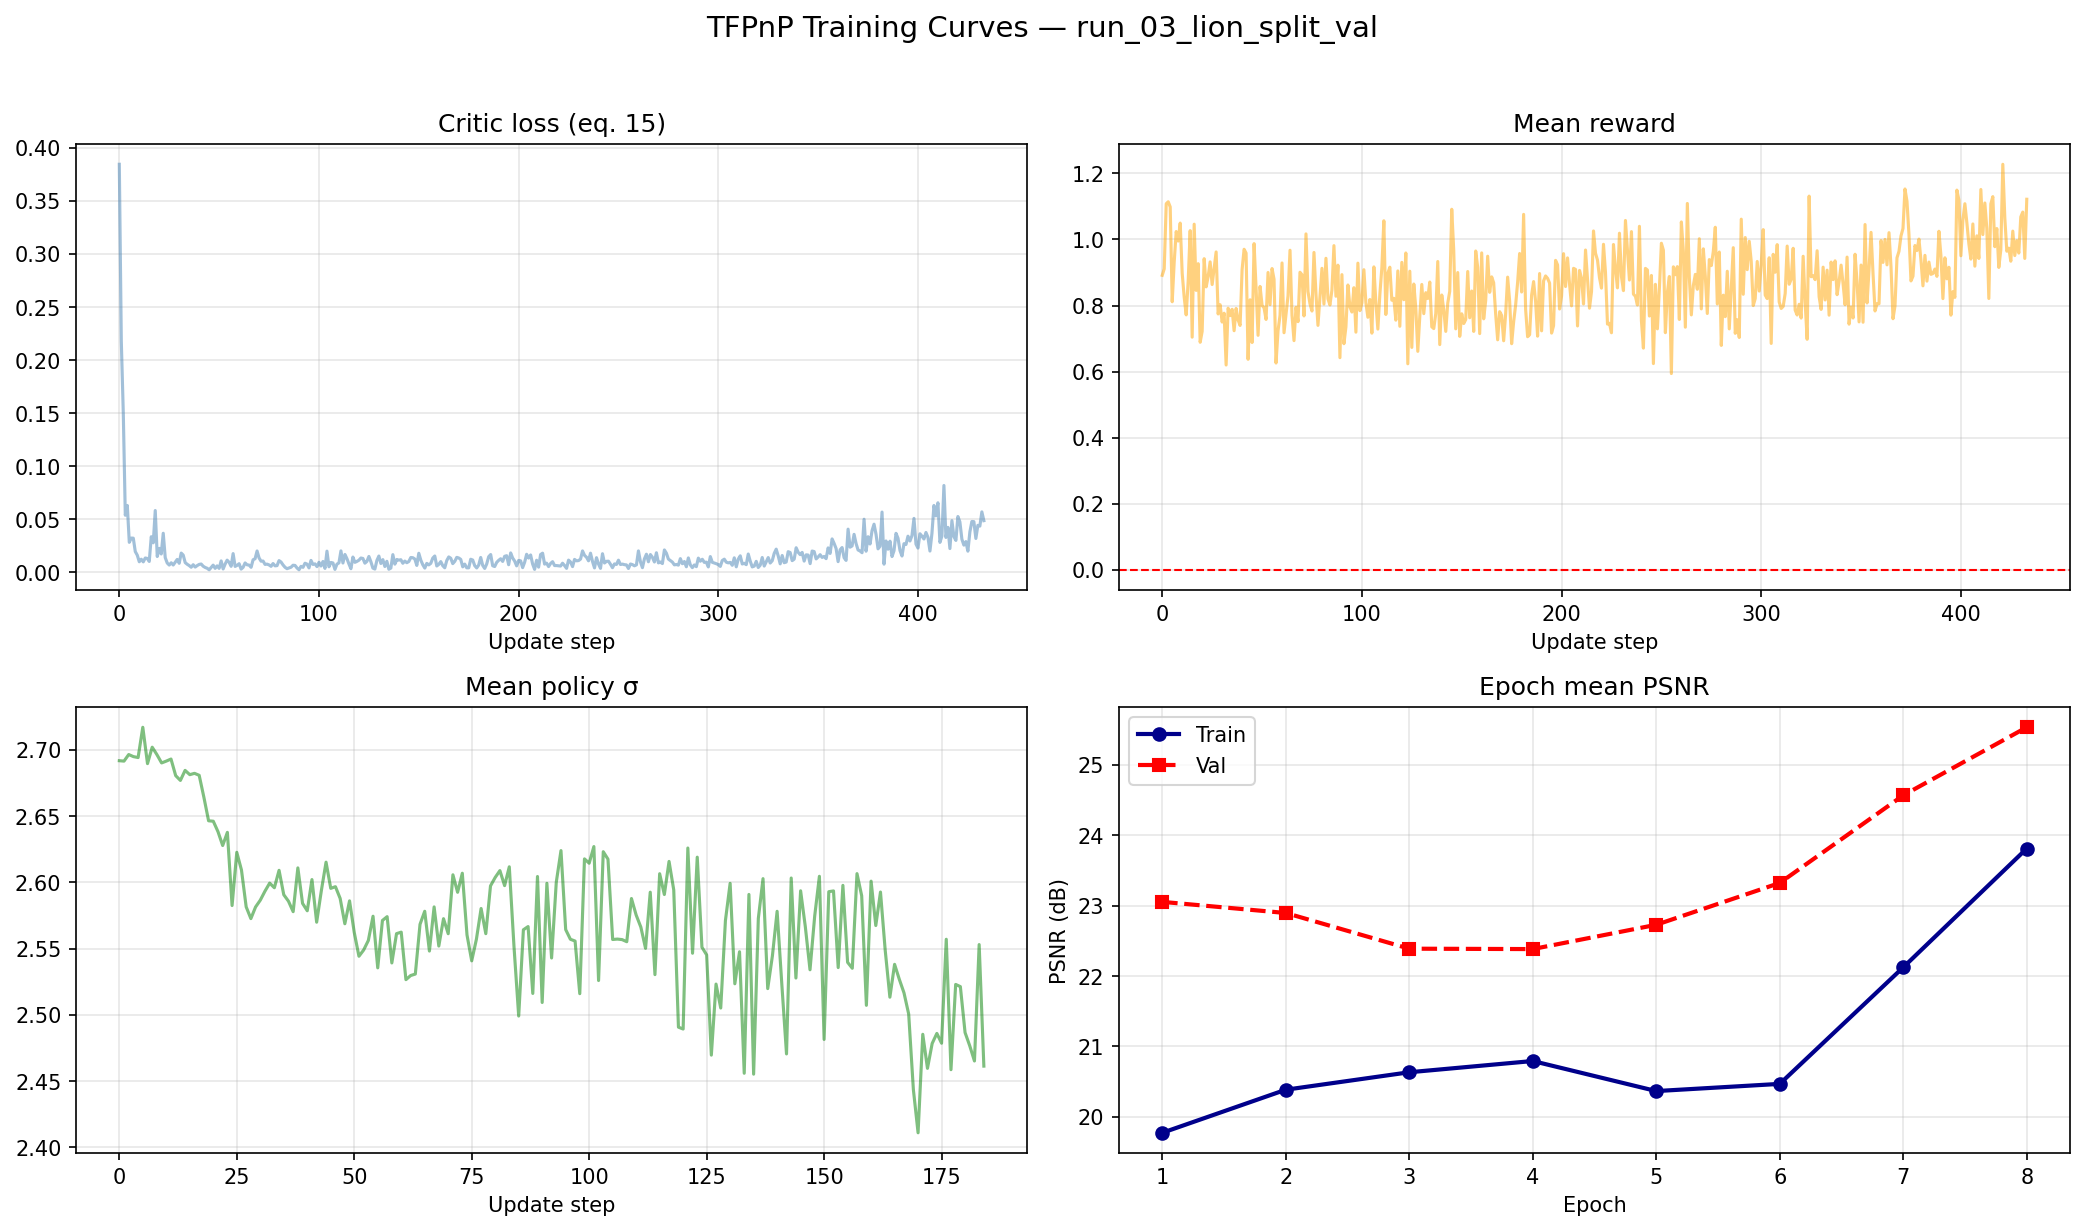

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

if train_log['critic_loss']:
    axes[0,0].plot(train_log['critic_loss'], alpha=0.5, color='steelblue')
    axes[0,0].set_title('Critic loss (eq. 15)')
    axes[0,0].set_xlabel('Update step'); axes[0,0].grid(True, alpha=0.3)

if train_log['mean_reward']:
    axes[0,1].plot(train_log['mean_reward'], alpha=0.5, color='orange')
    axes[0,1].axhline(0, color='red', ls='--', lw=1)
    axes[0,1].set_title('Mean reward')
    axes[0,1].set_xlabel('Update step'); axes[0,1].grid(True, alpha=0.3)

if train_log.get('mean_sigma'):
    axes[1,0].plot(train_log['mean_sigma'], alpha=0.5, color='green')
    axes[1,0].set_title('Mean policy σ')
    axes[1,0].set_xlabel('Update step'); axes[1,0].grid(True, alpha=0.3)

if train_log['epoch_psnr']:
    epochs = range(1, len(train_log['epoch_psnr'])+1)
    axes[1,1].plot(epochs, train_log['epoch_psnr'], 'o-', color='darkblue', lw=2, label='Train')
    if train_log.get('val_psnr'):
        axes[1,1].plot(epochs, train_log['val_psnr'], 's--', color='red', lw=2, label='Val')
    axes[1,1].set_title('Epoch mean PSNR')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('PSNR (dB)')
    axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'TFPnP Training Curves — {EXPERIMENT_NAME}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(output_dir / "01_training_curves.pdf", bbox_inches="tight")
plt.show()

We can load and inspect the best checkpoint

Loaded: checkpoint_best_val.pth
  Epoch: 8, Train PSNR: 23.81 dB, Val PSNR: 25.54 dB


/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/torch.py:63: UserWarning: The parameter initial_value should be contiguous. It has been automatically made contiguous. Use `ts.link(x.contiguous())' to inhibit this warning. 
  warnings.warn(


  Decision 0: σ=['1.0', '1.5', '4.5', '1.0', '1.0'], μ=['10.0', '100.0', '10.1', '10.3', '99.2'], PSNR=18.6 dB
  Decision 1: σ=['1.7', '2.2', '3.3', '1.4', '1.7'], μ=['10.0', '96.3', '16.1', '23.4', '65.7'], PSNR=21.4 dB
  Decision 2: σ=['2.8', '3.1', '2.7', '2.6', '1.8'], μ=['15.1', '60.8', '29.2', '29.7', '48.3'], PSNR=23.6 dB
  Decision 3: σ=['2.8', '3.1', '2.6', '2.7', '1.8'], μ=['17.5', '56.0', '30.4', '30.2', '46.6'], PSNR=25.3 dB
  Decision 4: σ=['2.6', '2.8', '2.8', '2.1', '2.1'], μ=['12.6', '67.2', '28.4', '30.5', '47.4'], PSNR=26.0 dB
  Decision 5: σ=['2.2', '2.6', '2.9', '1.6', '2.1'], μ=['10.2', '86.4', '20.7', '23.7', '54.7'], PSNR=26.2 dB

Total ADMM steps: 30


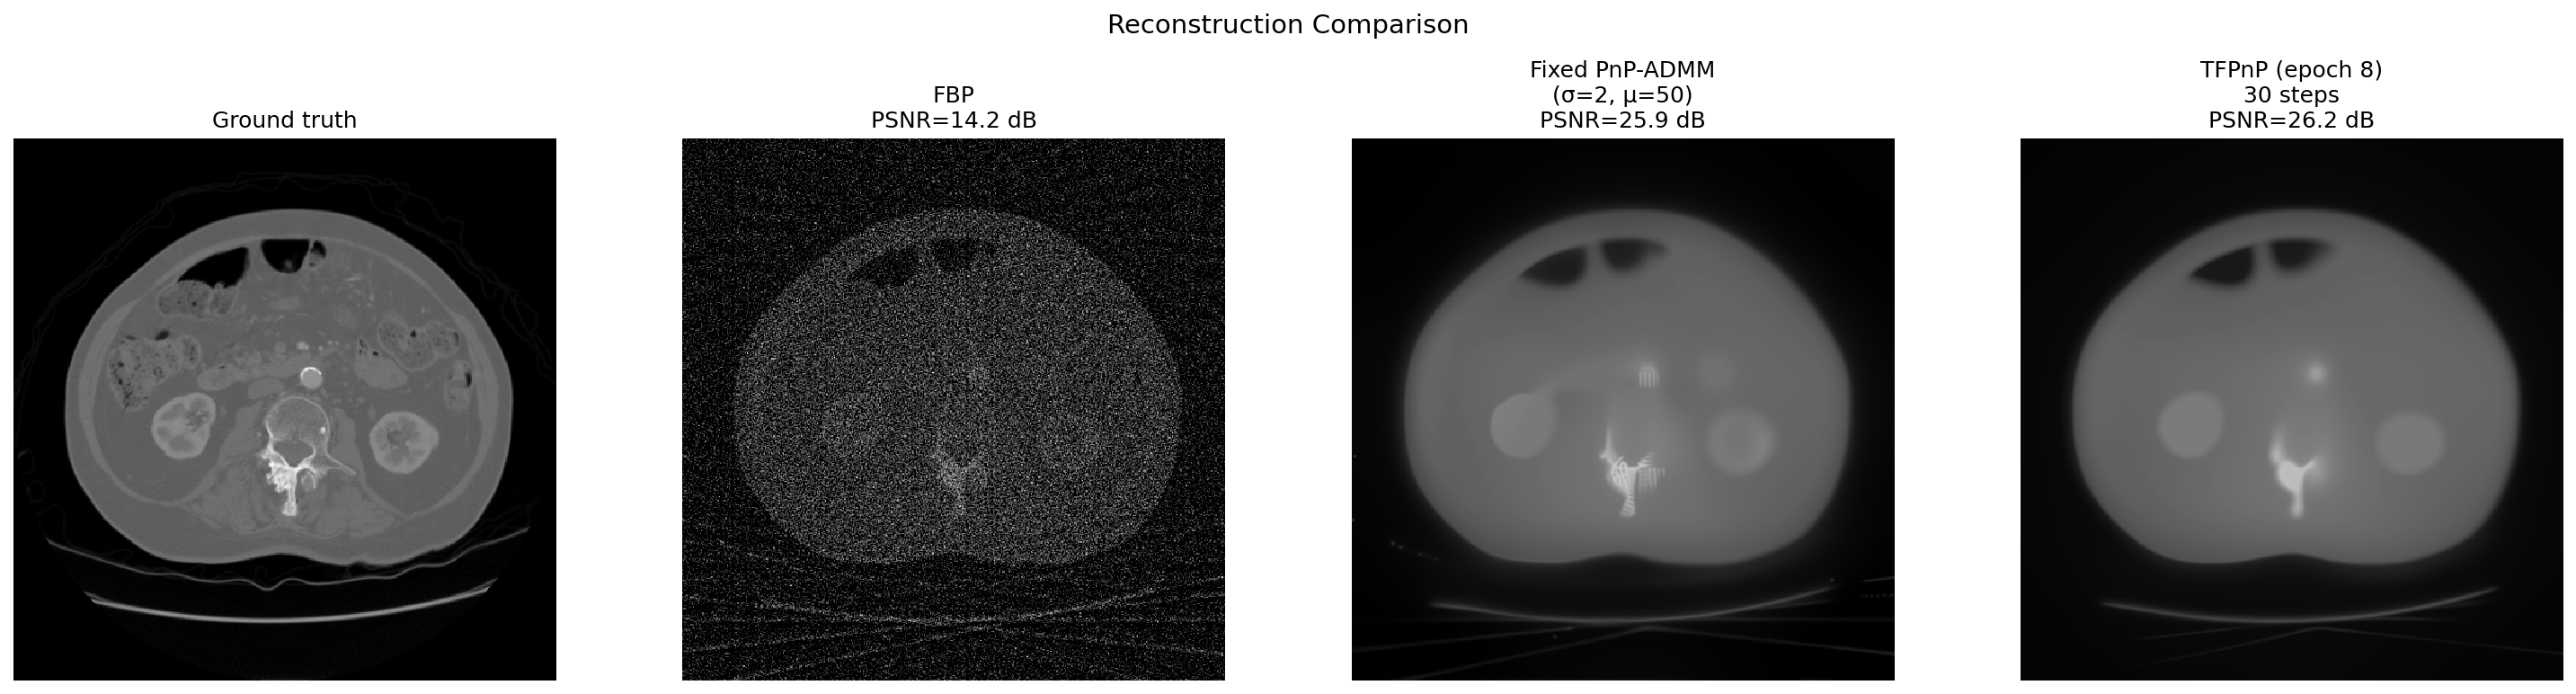

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# EVALUATE BEST CHECKPOINT — compare TFPnP to baselines
# ═══════════════════════════════════════════════════════════════════════════

# ── Load the best checkpoint (saved during training) ──────────────────────
CHECKPOINT_PATH = ckpt_dir / "checkpoint_best_val.pth"
if not CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH = ckpt_dir / "checkpoint_best.pth"

ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
print(f"Loaded: {CHECKPOINT_PATH.name}")
print(f"  Epoch: {ckpt['epoch']}, Train PSNR: {ckpt['mean_psnr']:.2f} dB", end="")
if 'val_psnr' in ckpt:
    print(f", Val PSNR: {ckpt['val_psnr']:.2f} dB")
else:
    print()

# Recreate the policy with SAME architecture and ranges as training
# If these don't match, the weights won't produce correct outputs
policy_best = ResNetActor_ADMM(in_channels=5, n_action_steps=5,
                                sigma_range=(1.0, 5.0),
                                mu_range=(10.0, 100.0)).to(device)
policy_best.load_state_dict(ckpt['policy_state_dict'])  # Load trained weights
policy_best.eval()  # Disable dropout, fix batchnorm stats

# ── Generate a test problem ───────────────────────────────────────────────

test_gt = train_images[0]  # Use first image (policy has seen this during training)

# Forward project: gt → sinogram (simulate the CT scan)
sino_clean = op.forward(test_gt)

# SCALE bridges LION's sinogram units to µ units
# LION sums µ values along rays without pixel spacing, so sinogram has different units
SCALE = sino_clean.max() / test_gt.max()

# Add 5% Gaussian noise to sinogram (simulating measurement noise)
torch.manual_seed(99)  # Fixed seed so we get the same noise every time
sino_noisy = sino_clean / SCALE + NOISE_STD * (sino_clean / SCALE).std() * torch.randn_like(sino_clean)
y = sino_noisy * SCALE  # Back to raw sinogram units for ADMM

# ── Baseline 1: FBP ──────────────────────────────────────────────────────
# Filtered backprojection — simplest reconstruction, no iterative refinement
x_fbp = lion_fbp(y, op)
# ls_scale: find optimal scalar α such that α×recon best matches gt
# This corrects the overall brightness (FBP has arbitrary scaling)
x_fbp = ls_scale(test_gt, x_fbp).clamp(min=0)
fbp_psnr = psnr(test_gt, x_fbp)

# ── Baseline 2: Fixed PnP-ADMM ───────────────────────────────────────────
# Uses hand-tuned σ=2, μ=50 (our best fixed params from NB08)
# This is the "oracle" we're trying to beat — but it uses the SAME params for every image
x_fix = x_fbp.clone(); z_fix = x_fbp.clone(); u_fix = torch.zeros_like(x_fbp)
with torch.no_grad():
    for k in range(20):  # 20 ADMM iterations with fixed params
        x_fix, z_fix, u_fix = admm_step(x_fix, z_fix, u_fix, y, sigma=2.0, mu=20.0)
x_fix_scaled = ls_scale(test_gt, x_fix).clamp(min=0)
fix_psnr = psnr(test_gt, x_fix_scaled)

# ── TFPnP: learned policy controls ADMM ──────────────────────────────────
# The policy looks at the current state and decides σ,μ adaptively
x = x_fbp.clone(); z = x_fbp.clone(); u = torch.zeros_like(x_fbp)
noise_level = torch.tensor([NOISE_STD], device=device)
n_steps_run = 0

with torch.no_grad():  # No gradients needed — just inference
    for t in range(6):  # Up to N=6 decisions
        iter_frac = torch.tensor([t / 6.0], device=device)  # How far along are we? (0→1)

        # Policy reads the 5-channel state and outputs:
        #   stop_logits: should I stop? (2 logits → softmax → P(stop))
        #   sigma_seq: σ values for next 5 ADMM steps
        #   mu_seq: μ values for next 5 ADMM steps
        stop_logits, sigma_seq, mu_seq = policy_best(
            _to_4d(x), _to_4d(z), _to_4d(u), noise_level, iter_frac)

        # Check if policy wants to stop (early termination)
        stop_prob = F.softmax(stop_logits, dim=-1)[0, 1].item()
        if t > 0 and stop_prob > 0.5:
            print(f"  Policy chose to STOP at decision {t} (P(stop)={stop_prob:.2f})")
            break

        # Run 5 ADMM steps with the policy's chosen parameters
        for i in range(5):
            x, z, u = admm_step(x, z, u, y,
                                 sigma=sigma_seq[0, i],   # Denoising strength for this step
                                 mu=mu_seq[0, i])          # Data fidelity weight for this step
            n_steps_run += 1

        print(f"  Decision {t}: σ={[f'{v:.1f}' for v in sigma_seq[0].tolist()]}, "
              f"μ={[f'{v:.1f}' for v in mu_seq[0].tolist()]}, "
              f"PSNR={psnr(test_gt, x):.1f} dB")

# Final ls_scale to correct overall brightness for fair PSNR comparison
x_tfpnp = ls_scale(test_gt, x).clamp(min=0)
tfpnp_psnr = psnr(test_gt, x_tfpnp)

print(f"\nTotal ADMM steps: {n_steps_run}")

# ── Display all four results side by side ─────────────────────────────────
gt_disp = test_gt[0].cpu().numpy()
vmin, vmax = gt_disp.min(), gt_disp.max()  # Shared display range for fair comparison

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(gt_disp, vmin=vmin, vmax=vmax)
axes[0].set_title("Ground truth"); axes[0].axis("off")

axes[1].imshow(x_fbp[0].cpu().numpy(), vmin=vmin, vmax=vmax)
axes[1].set_title(f"FBP\nPSNR={fbp_psnr:.1f} dB"); axes[1].axis("off")

axes[2].imshow(x_fix_scaled[0].cpu().numpy(), vmin=vmin, vmax=vmax)
axes[2].set_title(f"Fixed PnP-ADMM\n(σ=2, μ=50)\nPSNR={fix_psnr:.1f} dB"); axes[2].axis("off")

axes[3].imshow(x_tfpnp[0].cpu().numpy(), vmin=vmin, vmax=vmax)
axes[3].set_title(f"TFPnP (epoch {ckpt['epoch']})\n{n_steps_run} steps\nPSNR={tfpnp_psnr:.1f} dB"); axes[3].axis("off")

plt.suptitle("Reconstruction Comparison", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(output_dir / "02_best_checkpoint_comparison.pdf", bbox_inches="tight")
plt.show()

## 11. Summary

### What this notebook implements

| Component | Equation | Status |
|-----------|----------|--------|
| Episode collection | Algorithm 1, lines 3–9 | ✓ |
| Critic TD loss | eq. 15 | ✓ |
| π₁ REINFORCE | eq. 16 | ✓ |
| π₂ model-based DDPG | eq. 17 | ✓ |
| EMA target critic | line 15 | ✓ |
| Checkpoint save/load | — | ✓ |

### Results for meeting 3

- FBP baseline: ~20 dB
- Fixed PnP-ADMM + DRUNet: ~24–30 dB (depending on σ, μ)
- TFPnP (after training): check epoch_psnr curve above

### What comes next

Fine-tune hyperparameters (η, learning rates, σ/μ ranges), run for more epochs, compare against fixed baselines on a held-out test set.

## 12. Package Verification

Verify all training components import correctly from the `ct_tfpnp` package.

In [ ]:
# ── Verify LIONsolver integration ────────────────────────────────────────
print("Verifying TFPnPSolver (LIONsolver integration)...\n")

from ct_tfpnp.models.tfpnp_model import TFPnPModel
from ct_tfpnp.optimisers.tfpnp_solver import TFPnPSolver, TFPnPSolverParams

from LION.optimizers.LIONsolver import LIONsolver
from LION.models.LIONmodel import LIONmodel

print(f"  TFPnPModel inherits LIONmodel   : {issubclass(TFPnPModel, LIONmodel)}")
print(f"  TFPnPSolver inherits LIONsolver : {issubclass(TFPnPSolver, LIONsolver)}")

# Use geometry from our experiment
geo = experiment.experiment_params.geometry

test_model = TFPnPModel(geometry=geo)
test_optim = torch.optim.Adam(test_model.policy.parameters(), lr=1e-4)

test_solver = TFPnPSolver(
    model=test_model,
    optimizer=test_optim,
    geometry=geo,
    device=device,
    denoiser_path=DENOISER_PATH,
    verbose=False,
)

print(f"\n  Model policy params  : {sum(p.numel() for p in test_model.policy.parameters()):,}")
print(f"  Model critic params  : {sum(p.numel() for p in test_model.critic.parameters()):,}")
print(f"  Denoiser params      : {sum(p.numel() for p in test_solver.denoiser.parameters()):,}")
print(f"  Replay buffer cap    : {test_solver.replay_buffer.capacity}")
print(f"  ADMM n_x_steps       : {test_solver.admm_step.n_x_steps}")

print(f"\n  Citation:\n  {TFPnPModel.cite()}")

print("\n" + "=" * 50)
print("✓ TFPnPSolver ready — inherits LIONsolver")
print("  Submit: sbatch slurm/train_tfpnp.sh")
print("=" * 50)

# Clean up to free GPU memory
del test_solver, test_model, test_optim
torch.cuda.empty_cache()